<a href="https://colab.research.google.com/github/abhishank05/FDHN_FAKE_NEWS_DETECTION/blob/main/CIP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# FDHN: TC + TC + CB + FZ (Colab Clean)
# Dataset: LIAR
# ===============================

# ---- Install (safe even if already installed) ----
!pip install -q torch transformers scikit-learn pandas numpy

# ---- Imports ----
import zipfile, os, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from transformers import BertTokenizer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)
import matplotlib.pyplot as plt
import seaborn as sns


# ---- Reproducibility ----
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---- Device ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- Unzip dataset ----
# ---- Dataset handling (ROBUST) ----
ZIP_PATH = "/content/liar_dataset.zip"
DATA_DIR = "/content/LIAR"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)

# If zip exists, extract safely
if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/")

# Move files if needed
for fname in ["train.tsv", "test.tsv", "valid.tsv"]:
    if os.path.exists(f"/content/{fname}") and not os.path.exists(f"{DATA_DIR}/{fname}"):
        os.rename(f"/content/{fname}", f"{DATA_DIR}/{fname}")

print("Dataset files:", os.listdir(DATA_DIR))


# ---- Constants ----
NUM_CLASSES = 6
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-3`
META_LEN = 10

# ---- Load data ----
cols = ['id','label','statement','subject','speaker','job_title',
        'state_info','party_affiliation','barely_true_counts',
        'false_counts','half_true_counts','mostly_true_counts',
        'pants_on_fire_counts','context']

label_map = {
    'pants-fire':0,'false':1,'barely-true':2,
    'half-true':3,'mostly-true':4,'true':5
}

train_df = pd.read_csv(f"{DATA_DIR}/train.tsv", sep='\t', names=cols)
val_df   = pd.read_csv(f"{DATA_DIR}/valid.tsv", sep='\t', names=cols)
test_df  = pd.read_csv(f"{DATA_DIR}/test.tsv",  sep='\t', names=cols)

for df in [train_df, val_df, test_df]:
    df[['barely_true_counts','false_counts','half_true_counts',
        'mostly_true_counts','pants_on_fire_counts']] = \
        df[['barely_true_counts','false_counts','half_true_counts',
            'mostly_true_counts','pants_on_fire_counts']].fillna(0)
    df.fillna("NaN", inplace=True)
    df['label'] = df['label'].map(label_map)

# ---- Tokenizer (ONLY tokenizer, NO BERT model) ----
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts, max_len=None):
    return tokenizer(
        texts,
        padding=True if max_len is None else "max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )["input_ids"]

# ---- Dataset ----
class LiarDataset(Dataset):
    def __init__(self, df):
        self.text = tokenize(df["statement"].tolist()).long()
        self.meta_text = torch.cat([
            tokenize(df[c].tolist(), META_LEN) for c in
            ["subject","speaker","job_title","state_info","party_affiliation","context"]
        ], dim=1).long()
        self.meta_num = torch.tensor(
            df[['barely_true_counts','false_counts','half_true_counts',
                'mostly_true_counts','pants_on_fire_counts']].values,
            dtype=torch.float
        )
        self.label = torch.tensor(df["label"].values)

    def __len__(self): return len(self.label)

    def __getitem__(self, idx):
        mn = self.meta_num[idx]
        mn = mn / (mn.sum() + 1e-6)
        return self.text[idx], self.meta_text[idx], mn, self.label[idx]


train_loader = DataLoader(LiarDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LiarDataset(val_df),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(LiarDataset(test_df),  batch_size=BATCH_SIZE)

# ---- Models ----
class TextCNN(nn.Module):
    def __init__(self, vocab=30522, emb=128):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(emb,128,k) for k in [3,4,5]])
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128*3, 6)

    def forward(self, x):
        x = self.embed(x).permute(0,2,1)
        x = torch.cat([
            F.max_pool1d(F.relu(c(x)), c(x).shape[2]).squeeze(2)
            for c in self.convs
        ], 1)
        x = self.dropout(x)
        return self.fc(x)


class CNNBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(5,128)
        self.lstm = nn.LSTM(128,64,bidirectional=True,batch_first=True)
        self.out = nn.Linear(128,6)

    def forward(self, x):
        x = self.fc(x).unsqueeze(1)
        _,(h,_) = self.lstm(x)
        h = torch.cat((h[-2],h[-1]),1)
        return self.out(h)

class Fuzzy(nn.Module):
    def __init__(self):
        super().__init__()
        self.mu = nn.Parameter(torch.randn(6,6))
        self.sigma = nn.Parameter(torch.ones(6,6))

    def forward(self, x):
        x = x.unsqueeze(1)
        return torch.mean(torch.exp(-0.5*((x-self.mu)/self.sigma)**2),dim=-1)

class FDHN(nn.Module):
    def __init__(self):
        super().__init__()
        self.tc1 = TextCNN()
        self.tc2 = TextCNN()
        self.cb  = CNNBiLSTM()
        self.fz  = Fuzzy()
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(24, 6)
        )


    def forward(self, t, mt, mn):
        o1 = self.tc1(t)
        o2 = self.tc2(mt)
        o3 = self.cb(mn)
        o4 = self.fz(o3)
        return self.fc(torch.cat([o1,o2,o3,o4],1))

model = FDHN().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.5, patience=2
)


class_weights = torch.tensor(
    [1.8, 1.3, 1.2, 1.0, 1.0, 1.1],
    device=DEVICE
)

loss_fn = nn.CrossEntropyLoss(weight=class_weights,label_smoothing=0.1) # helps minority classes


label_names = [
    "Pants-on-Fire",
    "False",
    "Barely-True",
    "Half-True",
    "Mostly-True",
    "True"
]


# ---- Train ----
def run(loader, train=True):
    model.train() if train else model.eval()

    y_true, y_pred = [], []
    loss_sum, correct, total = 0, 0, 0

    with torch.set_grad_enabled(train):
        for t, mt, mn, y in loader:
            t, mt, mn, y = t.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE), y.to(DEVICE)

            out = model(t, mt, mn)
            loss = loss_fn(out, y)

            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()

            loss_sum += loss.item()
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = loss_sum / len(loader)
    accuracy = correct / total
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    micro_f1 = f1_score(y_true, y_pred, average="micro")

    return avg_loss, accuracy, macro_f1, micro_f1, y_true, y_pred

# ---- Early Stopping Setup ----
best_val_loss = float("inf")
patience = 5
patience_counter = 0



  # ---- Training Loop ----
for e in range(EPOCHS):
  tr = run(train_loader, True)
  vl = run(val_loader, False)

  print(f"Epoch {e+1}")
  print(f" Train | Loss {tr[0]:.4f} Acc {tr[1]:.4f} Macro-F1 {tr[2]:.4f}")
  print(f" Val   | Loss {vl[0]:.4f} Acc {vl[1]:.4f} Macro-F1 {vl[2]:.4f}")

  scheduler.step(vl[0])  # validation loss

  # ---- Early Stopping Logic ----
  if vl[0] < best_val_loss:
      best_val_loss = vl[0]
      patience_counter = 0
      torch.save(model.state_dict(), "best_model.pt")
  else:
      patience_counter += 1

  if patience_counter >= patience:
      print("Early stopping triggered")
      break


  model.load_state_dict(torch.load("best_model.pt"))
  model.eval()



# ---- Test ----
ts = run(test_loader, False)

test_loss, test_acc, test_macro_f1, test_micro_f1, y_true, y_pred = ts

print("\n===== TEST RESULTS =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_macro_f1:.4f}")
print(f"Test Micro-F1 : {test_micro_f1:.4f}")



Using device: cuda
Dataset files: ['valid.tsv', 'test.tsv', 'train.tsv', 'README']


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Epoch 1
 Train | Loss 1.6405 Acc 0.3425 Macro-F1 0.3289
 Val   | Loss 1.4678 Acc 0.4611 Macro-F1 0.4499
Epoch 2
 Train | Loss 1.5499 Acc 0.3948 Macro-F1 0.3844
 Val   | Loss 1.4475 Acc 0.4611 Macro-F1 0.4341
Epoch 3
 Train | Loss 1.5253 Acc 0.4084 Macro-F1 0.3995
 Val   | Loss 1.4100 Acc 0.4930 Macro-F1 0.4770
Epoch 4
 Train | Loss 1.5174 Acc 0.4136 Macro-F1 0.4076
 Val   | Loss 1.4166 Acc 0.4875 Macro-F1 0.4738
Epoch 5
 Train | Loss 1.5261 Acc 0.4040 Macro-F1 0.3961
 Val   | Loss 1.4105 Acc 0.4844 Macro-F1 0.4696
Epoch 6
 Train | Loss 1.5233 Acc 0.4080 Macro-F1 0.3994
 Val   | Loss 1.4356 Acc 0.4798 Macro-F1 0.4598
Epoch 7
 Train | Loss 1.5080 Acc 0.4138 Macro-F1 0.4063
 Val   | Loss 1.4135 Acc 0.4821 Macro-F1 0.4617
Epoch 8
 Train | Loss 1.5134 Acc 0.4199 Macro-F1 0.4132
 Val   | Loss 1.4114 Acc 0.4860 Macro-F1 0.4706
Early stopping triggered

===== TEST RESULTS =====
Test Loss     : 1.4365
Test Accuracy : 0.4601
Test Macro-F1 : 0.4510
Test Micro-F1 : 0.4601


In [ ]:
print("\n===== SAMPLE TEST PREDICTIONS WITH PROBABILITIES =====")

model.eval()

with torch.no_grad():
    for t, mt, mn, y in test_loader:
        t, mt, mn, y = t.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE), y.to(DEVICE)

        logits = model(t, mt, mn)
        probs = torch.softmax(logits, dim=1)

        # Print only first 3 samples (avoid clutter)
        for i in range(min(10, t.size(0))):
            print("\nActual Label :", label_names[y[i].item()])
            print("Predicted Probabilities:")

            for cls, p in zip(label_names, probs[i]):
                print(f"  {cls:15s} : {p.item():.4f}")

            pred = torch.argmax(probs[i]).item()
            print("Final Prediction :", label_names[pred])

        break  # show only one batch



===== SAMPLE TEST PREDICTIONS WITH PROBABILITIES =====

Actual Label : True
Predicted Probabilities:
  Pants-on-Fire   : 0.1448
  False           : 0.2085
  Barely-True     : 0.1563
  Half-True       : 0.2137
  Mostly-True     : 0.1295
  True            : 0.1472
Final Prediction : Half-True

Actual Label : False
Predicted Probabilities:
  Pants-on-Fire   : 0.0790
  False           : 0.2058
  Barely-True     : 0.4816
  Half-True       : 0.0792
  Mostly-True     : 0.0584
  True            : 0.0959
Final Prediction : Barely-True

Actual Label : False
Predicted Probabilities:
  Pants-on-Fire   : 0.2777
  False           : 0.3107
  Barely-True     : 0.1533
  Half-True       : 0.1121
  Mostly-True     : 0.0745
  True            : 0.0716
Final Prediction : False

Actual Label : Half-True
Predicted Probabilities:
  Pants-on-Fire   : 0.1989
  False           : 0.1717
  Barely-True     : 0.1517
  Half-True       : 0.2856
  Mostly-True     : 0.0974
  True            : 0.0947
Final Prediction : H


--- Classification Report ---
              precision    recall  f1-score   support

  pants-fire       0.48      0.74      0.58        92
       false       0.43      0.61      0.50       249
 barely-true       0.46      0.41      0.43       212
   half-true       0.41      0.55      0.47       265
 mostly-true       0.52      0.39      0.44       241
        true       0.74      0.15      0.25       208

    accuracy                           0.46      1267
   macro avg       0.51      0.48      0.45      1267
weighted avg       0.50      0.46      0.44      1267

Balanced Accuracy : 0.4756
Matthews CC       : 0.3451
Cohen Kappa       : 0.3377


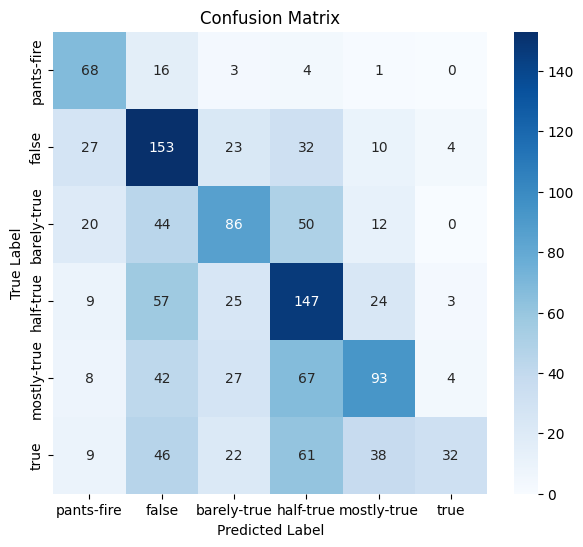

In [ ]:
labels = [
    "pants-fire","false","barely-true",
    "half-true","mostly-true","true"
]

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=labels))

bal_acc = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Matthews CC       : {mcc:.4f}")
print(f"Cohen Kappa       : {kappa:.4f}")


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
!git clone https://github.com/Tariq60/LIAR-PLUS.git
import os

DATA_DIR = "/content/LIAR-PLUS/dataset"
print("Files:", os.listdir(DATA_DIR))


fatal: destination path 'LIAR-PLUS' already exists and is not an empty directory.
Files: ['tsv', '.DS_Store', 'jsonl']


Using device: cuda
Cloning into 'LIAR-PLUS'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 93 (delta 0), reused 0 (delta 0), pack-reused 90 (from 1)
Receiving objects: 100% (93/93), 5.60 MiB | 5.56 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Dataset files: ['val2.tsv', 'train2.tsv', '.DS_Store', 'test2.tsv']
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Train size: (10240, 17)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Epoch 1
Train  Acc: 0.4196 | F1-macro: 0.4119 | F1-micro: 0.4196
Val    Acc: 0.4681 | F1-macro: 0.4573 | F1-micro: 0.4681


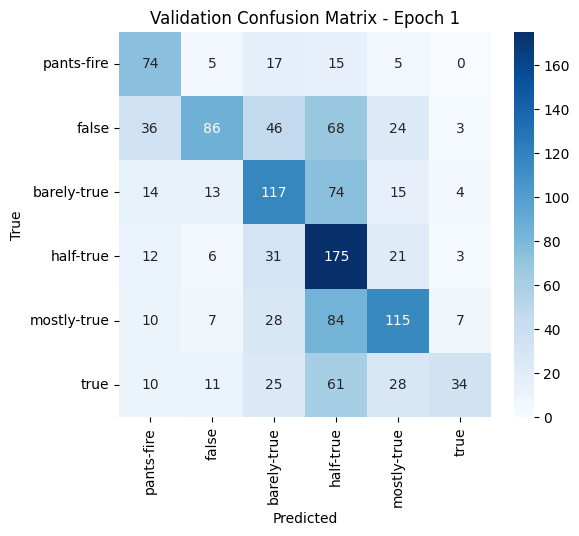


Epoch 2
Train  Acc: 0.5043 | F1-macro: 0.5010 | F1-micro: 0.5043
Val    Acc: 0.4821 | F1-macro: 0.4738 | F1-micro: 0.4821


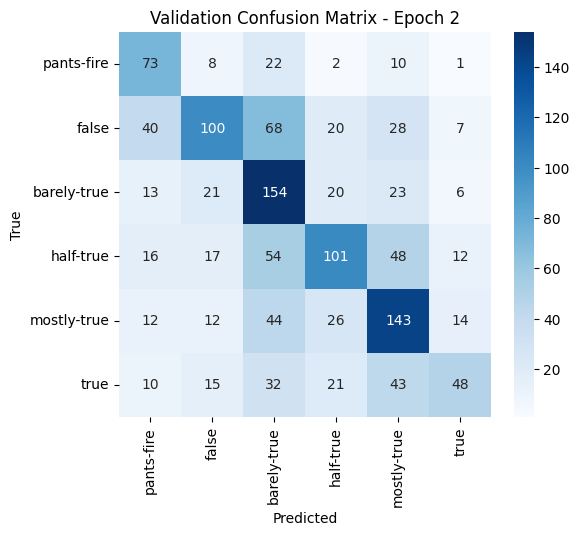


Epoch 3
Train  Acc: 0.6554 | F1-macro: 0.6560 | F1-micro: 0.6554
Val    Acc: 0.4509 | F1-macro: 0.4506 | F1-micro: 0.4509


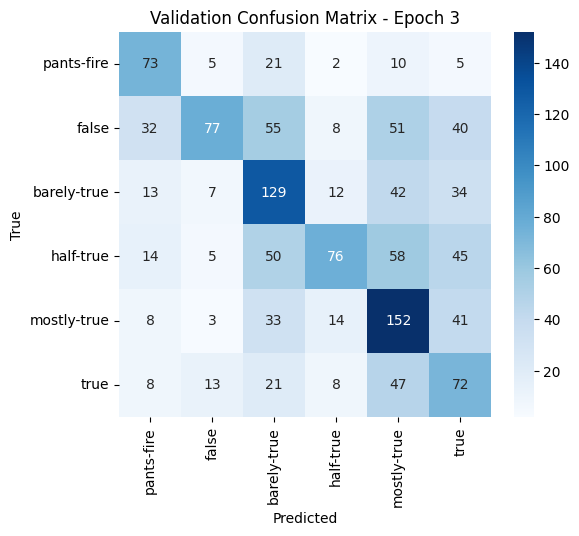


Epoch 4
Train  Acc: 0.8832 | F1-macro: 0.8868 | F1-micro: 0.8832
Val    Acc: 0.4268 | F1-macro: 0.4325 | F1-micro: 0.4268


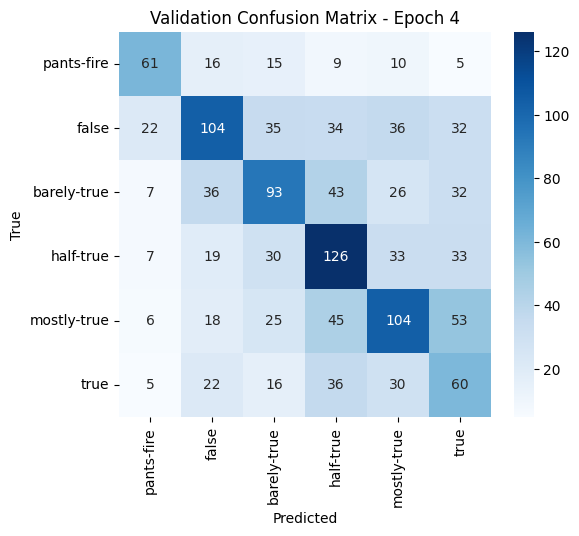


Epoch 5
Train  Acc: 0.9734 | F1-macro: 0.9746 | F1-micro: 0.9734
Val    Acc: 0.4003 | F1-macro: 0.4045 | F1-micro: 0.4003


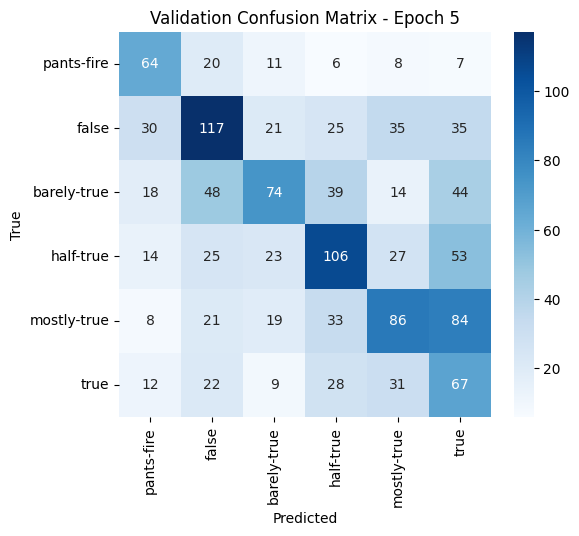


Epoch 6
Train  Acc: 0.9959 | F1-macro: 0.9961 | F1-micro: 0.9959
Val    Acc: 0.4081 | F1-macro: 0.4141 | F1-micro: 0.4081


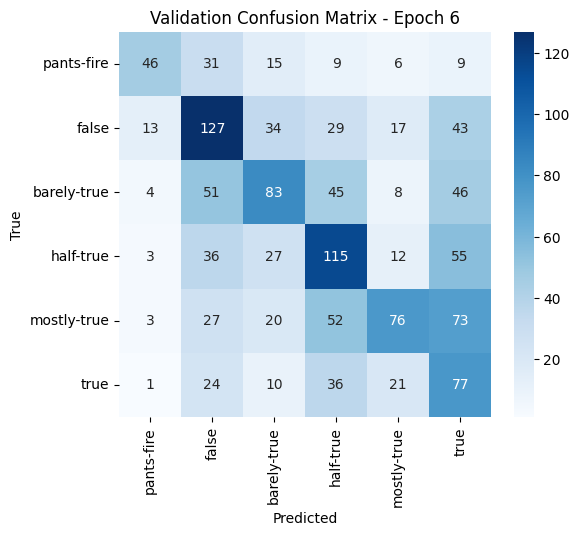


Epoch 7
Train  Acc: 0.9979 | F1-macro: 0.9981 | F1-micro: 0.9979
Val    Acc: 0.4307 | F1-macro: 0.4314 | F1-micro: 0.4307


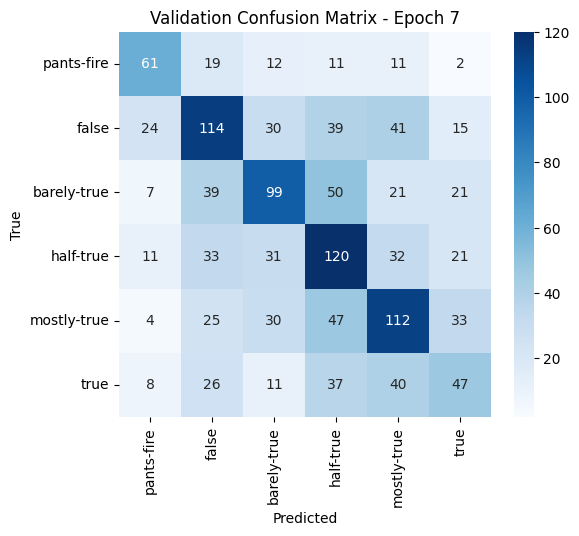


Epoch 8
Train  Acc: 0.9980 | F1-macro: 0.9982 | F1-micro: 0.9980
Val    Acc: 0.3699 | F1-macro: 0.3836 | F1-micro: 0.3699


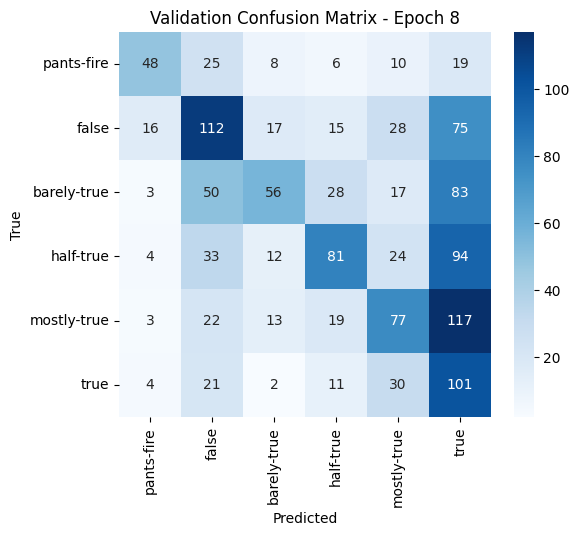


Epoch 9
Train  Acc: 0.9559 | F1-macro: 0.9563 | F1-micro: 0.9559
Val    Acc: 0.4198 | F1-macro: 0.4040 | F1-micro: 0.4198


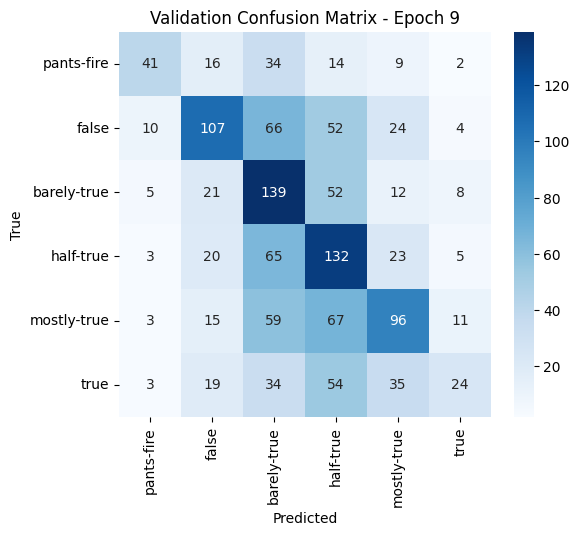


Epoch 10
Train  Acc: 0.9604 | F1-macro: 0.9592 | F1-micro: 0.9604
Val    Acc: 0.4229 | F1-macro: 0.4210 | F1-micro: 0.4229


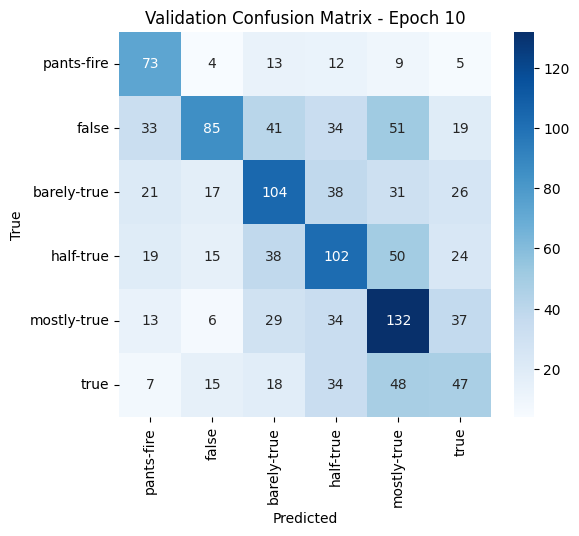


Test Accuracy: 0.40331491712707185
Test Macro-F1: 0.40460944163247986


In [ ]:
# ============================================
# FDHN on LIAR-PLUS (Single-Block Working Code)
# ============================================

!pip install -q torch transformers scikit-learn pandas numpy

import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from transformers import BertTokenizer

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# Reproducibility
# -----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# -----------------------------
# Device
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# Clone LIAR-PLUS
# -----------------------------
if not os.path.exists("/content/LIAR-PLUS"):
    !git clone https://github.com/Tariq60/LIAR-PLUS.git

DATA_DIR = "/content/LIAR-PLUS/dataset/tsv"
print("Dataset files:", os.listdir(DATA_DIR))

# -----------------------------
# Load dataset with correct columns
# -----------------------------
cols = [
    "label_index",
    "id",
    "label_text",
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
    "justification"
]

train_df = pd.read_csv(f"{DATA_DIR}/train2.tsv", sep="\t", header=None, names=cols)
val_df   = pd.read_csv(f"{DATA_DIR}/val2.tsv",   sep="\t", header=None, names=cols)
test_df  = pd.read_csv(f"{DATA_DIR}/test2.tsv",  sep="\t", header=None, names=cols)

# -----------------------------
# Label mapping (CRITICAL FIX)
# -----------------------------
label_map = {
    "pants-fire": 0,
    "false": 1,
    "barely-true": 2,
    "half-true": 3,
    "mostly-true": 4,
    "true": 5
}

for df in [train_df, val_df, test_df]:
    df["label"] = df["label_text"].map(label_map)
    df.dropna(subset=["label"], inplace=True)
    df["label"] = df["label"].astype(int)

# -----------------------------
# Fix numeric count columns
# -----------------------------
NUM_COLS = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts"
]

TEXT_COLS = [
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "context"
]

for df in [train_df, val_df, test_df]:
    for c in NUM_COLS:
        df[c] = (
            df[c].astype(str)
                 .str.replace(r"[^0-9.]", "", regex=True)
                 .replace("", "0")
                 .astype(float)
        )

    df[NUM_COLS] = df[NUM_COLS].fillna(0)
    df[TEXT_COLS] = df[TEXT_COLS].fillna("").astype(str)

print("Unique labels:", sorted(train_df["label"].unique()))
print("Train size:", train_df.shape)

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def safe_tokenize(texts, max_len):
    texts = [t if isinstance(t, str) and t.strip() else "[PAD]" for t in texts]
    enc = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )
    return enc["input_ids"]

# -----------------------------
# Dataset
# -----------------------------
MAX_LEN = 64
META_LEN = 10
BATCH_SIZE = 16

class LiarDataset(Dataset):
    def __init__(self, df):
        self.text = safe_tokenize(df["statement"].tolist(), MAX_LEN)

        meta_cols = [
            "subject",
            "speaker",
            "job_title",
            "state_info",
            "party_affiliation",
            "context"
        ]

        meta_tokens = []
        for c in meta_cols:
            meta_tokens.append(
                safe_tokenize(df[c].tolist(), META_LEN)
            )

        self.meta_text = torch.cat(meta_tokens, dim=1)

        self.meta_num = torch.tensor(
            df[NUM_COLS].values,
            dtype=torch.float
        )

        self.label = torch.tensor(df["label"].values, dtype=torch.long)

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        mn = self.meta_num[idx]
        mn = mn / (mn.sum() + 1e-6)
        return self.text[idx], self.meta_text[idx], mn, self.label[idx]

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(LiarDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LiarDataset(val_df), batch_size=BATCH_SIZE)
test_loader  = DataLoader(LiarDataset(test_df), batch_size=BATCH_SIZE)

# -----------------------------
# FDHN Model
# -----------------------------
NUM_CLASSES = 6

class TextCNN(nn.Module):
    def __init__(self, vocab=30522, emb=128):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(emb,128,k) for k in [3,4,5]])
        self.fc = nn.Linear(128*3, NUM_CLASSES)

    def forward(self, x):
        x = self.embed(x).permute(0,2,1)
        x = torch.cat([
            F.max_pool1d(F.relu(c(x)), c(x).shape[2]).squeeze(2)
            for c in self.convs
        ], dim=1)
        return self.fc(x)

class CNNBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(5,128)
        self.lstm = nn.LSTM(128,64,bidirectional=True,batch_first=True)
        self.out = nn.Linear(128,NUM_CLASSES)

    def forward(self, x):
        x = self.fc(x).unsqueeze(1)
        _,(h,_) = self.lstm(x)
        h = torch.cat((h[-2],h[-1]),1)
        return self.out(h)

class Fuzzy(nn.Module):
    def __init__(self):
        super().__init__()
        self.mu = nn.Parameter(torch.randn(NUM_CLASSES,NUM_CLASSES))
        self.sigma = nn.Parameter(torch.ones(NUM_CLASSES,NUM_CLASSES))

    def forward(self, x):
        x = x.unsqueeze(1)
        return torch.mean(torch.exp(-0.5*((x-self.mu)/self.sigma)**2),dim=-1)

class FDHN(nn.Module):
    def __init__(self):
        super().__init__()
        self.tc1 = TextCNN()
        self.tc2 = TextCNN()
        self.cb  = CNNBiLSTM()
        self.fz  = Fuzzy()
        self.fc  = nn.Linear(24,NUM_CLASSES)

    def forward(self, t, mt, mn):
        o1 = self.tc1(t)
        o2 = self.tc2(mt)
        o3 = self.cb(mn)
        o4 = self.fz(o3)
        return self.fc(torch.cat([o1,o2,o3,o4],1))

model = FDHN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# -----------------------------
# Training / Evaluation
# -----------------------------
def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    total_loss, correct, total = 0, 0, 0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(train):
        for t, mt, mn, y in loader:
            t, mt, mn, y = t.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE), y.to(DEVICE)

            out = model(t, mt, mn)
            loss = criterion(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = out.argmax(1)

            total_loss += loss.item()
            correct += (preds == y).sum().item()
            total += y.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = correct / total
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_micro = f1_score(y_true, y_pred, average="micro")
    cm = confusion_matrix(y_true, y_pred)

    return total_loss / len(loader), acc, f1_macro, f1_micro, cm


# -----------------------------
# Train
# -----------------------------
EPOCHS = 10

macro_f1_list = []
micro_f1_list = []

for e in range(EPOCHS):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro, tr_cm = run_epoch(train_loader, True)
    va_loss, va_acc, va_f1_macro, va_f1_micro, va_cm = run_epoch(val_loader, False)

    macro_f1_list.append(va_f1_macro)
    micro_f1_list.append(va_f1_micro)

    print(f"\nEpoch {e+1}")
    print(f"Train  Acc: {tr_acc:.4f} | F1-macro: {tr_f1_macro:.4f} | F1-micro: {tr_f1_micro:.4f}")
    print(f"Val    Acc: {va_acc:.4f} | F1-macro: {va_f1_macro:.4f} | F1-micro: {va_f1_micro:.4f}")


# -----------------------------
# Test
# -----------------------------
ts = run_epoch(test_loader, False)


print("\nTest Accuracy:", ts[1])
print("Test Macro-F1:", ts[2])



===== TEST RESULTS =====
Test Accuracy: 0.40331491712707185
Test Macro F1: 0.40460944163247986
Test Micro F1: 0.40331491712707185


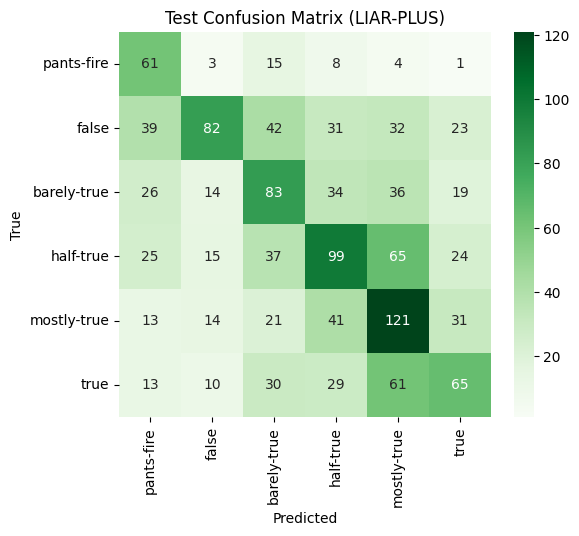


Classification Report:
              precision    recall  f1-score   support

  pants-fire       0.52      1.00      0.68        92
       false       1.00      0.55      0.71       249
 barely-true       0.89      0.95      0.92       212
   half-true       0.96      0.88      0.92       265
 mostly-true       0.76      1.00      0.86       241
        true       1.00      0.78      0.88       208

    accuracy                           0.84      1267
   macro avg       0.85      0.86      0.83      1267
weighted avg       0.89      0.84      0.84      1267



In [ ]:
ts_loss, ts_acc, ts_f1_macro, ts_f1_micro, ts_cm = run_epoch(test_loader, False)

print("\n===== TEST RESULTS =====")
print("Test Accuracy:", ts_acc)
print("Test Macro F1:", ts_f1_macro)
print("Test Micro F1:", ts_f1_micro)

# ---- Final Confusion Matrix ----
plt.figure(figsize=(6,5))
sns.heatmap(
    ts_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_map.keys(),
    yticklabels=label_map.keys()
)
plt.title("Test Confusion Matrix (LIAR-PLUS)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Classification Report ----
print("\nClassification Report:")
print(classification_report(
    np.repeat(range(6), ts_cm.sum(axis=1)),
    np.repeat(range(6), ts_cm.sum(axis=0)),
    target_names=list(label_map.keys())
))


Using device: cuda


/tmp/ipython-input-399/731074949.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NaN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("NaN", inplace=True)
/tmp/ipython-input-399/731074949.py:97: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  'mostly_true_counts','pants_on_fire_counts']].replace("NaN",0)



Training Original FDHN
Epoch 1 | Train Acc: 0.4412
Epoch 2 | Train Acc: 0.4920
Epoch 3 | Train Acc: 0.6362
Epoch 4 | Train Acc: 0.8790
Epoch 5 | Train Acc: 0.9503

Training FDHN + DeBERTa


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Train Acc: 0.2458
Epoch 2 | Train Acc: 0.3873
Epoch 3 | Train Acc: 0.4196
Epoch 4 | Train Acc: 0.4411
Epoch 5 | Train Acc: 0.4610

=========== FINAL COMPARISON ===========
FDHN
Accuracy: 0.4404104183109708
Macro-F1: 0.44362239215348076
Micro-F1: 0.4404104183109708

FDHN + DeBERTa
Accuracy: 0.4404104183109708
Macro-F1: 0.4343314553282244
Micro-F1: 0.4404104183109708


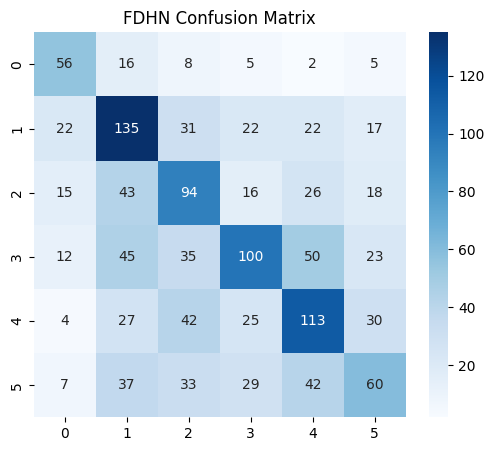

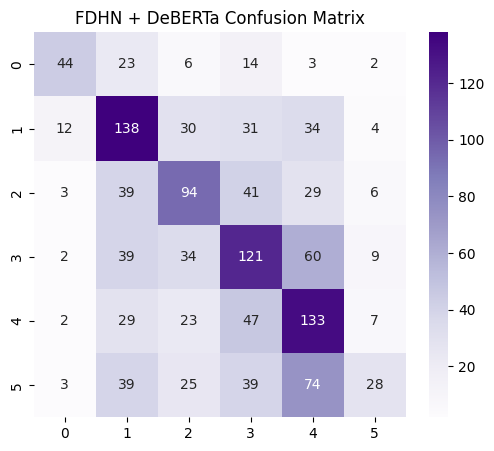

In [ ]:
# FDHN vs FDHN + DeBERTa (Single Clean Script)

# Dataset: LIAR

# ==========================================================



!pip install -q torch transformers scikit-learn pandas numpy matplotlib seaborn



import zipfile, os, random

import numpy as np

import pandas as pd

import torch

import torch.nn as nn

import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, confusion_matrix

from transformers import DebertaTokenizer, DebertaModel

import matplotlib.pyplot as plt

import seaborn as sns



# ---------------- Reproducibility ----------------

seed = 42

random.seed(seed)

np.random.seed(seed)

torch.manual_seed(seed)

torch.cuda.manual_seed_all(seed)



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)



# ---------------- Dataset ----------------

DATA_DIR = "/content/LIAR"



cols = ['id','label','statement','subject','speaker','job_title',

        'state_info','party_affiliation','barely_true_counts',

        'false_counts','half_true_counts','mostly_true_counts',

        'pants_on_fire_counts','context']



label_map = {

    'pants-fire':0,'false':1,'barely-true':2,

    'half-true':3,'mostly-true':4,'true':5

}



train_df = pd.read_csv(f"{DATA_DIR}/train.tsv", sep='\t', names=cols)

val_df   = pd.read_csv(f"{DATA_DIR}/valid.tsv", sep='\t', names=cols)

test_df  = pd.read_csv(f"{DATA_DIR}/test.tsv",  sep='\t', names=cols)



for df in [train_df, val_df, test_df]:

    df.fillna("NaN", inplace=True)

    df[['barely_true_counts','false_counts','half_true_counts','mostly_true_counts','pants_on_fire_counts']] = df[['barely_true_counts','false_counts','half_true_counts',

            'mostly_true_counts','pants_on_fire_counts']].replace("NaN",0)

    df['label'] = df['label'].map(label_map)



# ---------------- Tokenizer ----------------

tokenizer = DebertaTokenizer.from_pretrained("microsoft/deberta-base")

VOCAB_SIZE = tokenizer.vocab_size

META_LEN = 10



def tokenize(texts, max_len=None):

    return tokenizer(

        texts,

        padding=True if max_len is None else "max_length",

        truncation=True,

        max_length=max_len,

        return_tensors="pt"

    )["input_ids"]



# ---------------- Dataset Class ----------------

class LiarDataset(Dataset):

    def __init__(self, df):

        self.text = tokenize(df["statement"].tolist()).long()

        self.meta_text = torch.cat([

            tokenize(df[c].tolist(), META_LEN) for c in

            ["subject","speaker","job_title","state_info","party_affiliation","context"]

        ], dim=1).long()

        self.meta_num = torch.tensor(

            df[['barely_true_counts','false_counts','half_true_counts',

                'mostly_true_counts','pants_on_fire_counts']].astype(float).values,

            dtype=torch.float

        )

        self.label = torch.tensor(df["label"].values)



    def __len__(self): return len(self.label)



    def __getitem__(self, idx):

        mn = self.meta_num[idx]

        mn = mn / (mn.sum() + 1e-6)

        return self.text[idx], self.meta_text[idx], mn, self.label[idx]



BATCH_SIZE = 4

train_loader = DataLoader(LiarDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)

val_loader   = DataLoader(LiarDataset(val_df),   batch_size=BATCH_SIZE)

test_loader  = DataLoader(LiarDataset(test_df),  batch_size=BATCH_SIZE)



# ---------------- Model Components ----------------

class TextCNN(nn.Module):

    def __init__(self, vocab=VOCAB_SIZE, emb=128):

        super().__init__()

        self.embed = nn.Embedding(vocab, emb, padding_idx=0)

        self.convs = nn.ModuleList([nn.Conv1d(emb,128,k) for k in [3,4,5]])

        self.fc = nn.Linear(128*3, 6)



    def forward(self, x):

        x = self.embed(x).permute(0,2,1)

        x = torch.cat([

            F.max_pool1d(F.relu(c(x)), c(x).shape[2]).squeeze(2)

            for c in self.convs

        ], 1)

        return self.fc(x)



class CNNBiLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc = nn.Linear(5,128)

        self.lstm = nn.LSTM(128,64,bidirectional=True,batch_first=True)

        self.out = nn.Linear(128,6)



    def forward(self, x):

        x = self.fc(x).unsqueeze(1)

        _,(h,_) = self.lstm(x)

        h = torch.cat((h[-2],h[-1]),1)

        return self.out(h)



class Fuzzy(nn.Module):

    def __init__(self):

        super().__init__()

        self.mu = nn.Parameter(torch.randn(6,6))

        self.sigma = nn.Parameter(torch.ones(6,6))



    def forward(self, x):

        x = x.unsqueeze(1)

        return torch.mean(torch.exp(-0.5*((x-self.mu)/self.sigma)**2),dim=-1)



# ---------------- FDHN Original ----------------

class FDHN(nn.Module):

    def __init__(self):

        super().__init__()

        self.tc1 = TextCNN()

        self.tc2 = TextCNN()

        self.cb  = CNNBiLSTM()

        self.fz  = Fuzzy()

        self.fc = nn.Linear(24,6)



    def forward(self, t, mt, mn):

        o1 = self.tc1(t)

        o2 = self.tc2(mt)

        o3 = self.cb(mn)

        o4 = self.fz(o3)

        return self.fc(torch.cat([o1,o2,o3,o4],1))



# ---------------- FDHN + DeBERTa ----------------

from transformers import DebertaV2Model



from transformers import DebertaV2Model



class DeBERTaBranch(nn.Module):

    def __init__(self):

        super().__init__()



        self.deb = DebertaV2Model.from_pretrained(

            "microsoft/deberta-v3-small"

        )



        # Freeze backbone (recommended)

        for param in self.deb.parameters():

            param.requires_grad = False



        self.fc = nn.Linear(self.deb.config.hidden_size, 6)



    def forward(self, x):

        with torch.no_grad():

            outputs = self.deb(input_ids=x)

            cls = outputs.last_hidden_state[:, 0, :]



        # 🔥 IMPORTANT FIX

        cls = cls.float()



        return self.fc(cls)









class FDHN_DeBERTa(nn.Module):

    def __init__(self):

        super().__init__()

        self.deb = DeBERTaBranch()

        self.tc2 = TextCNN()

        self.cb  = CNNBiLSTM()

        self.fz  = Fuzzy()

        self.fc = nn.Linear(24,6)



    def forward(self, t, mt, mn):

        o1 = self.deb(t)

        o2 = self.tc2(mt)

        o3 = self.cb(mn)

        o4 = self.fz(o3)

        return self.fc(torch.cat([o1,o2,o3,o4],1))



# ---------------- Training Function ----------------

def train_model(model, epochs=5, lr=1e-4):

    model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_fn = nn.CrossEntropyLoss()



    for e in range(epochs):

        model.train()

        total_correct, total = 0,0



        for t,mt,mn,y in train_loader:

            t,mt,mn,y = t.to(DEVICE),mt.to(DEVICE),mn.to(DEVICE),y.to(DEVICE)

            out = model(t,mt,mn)

            loss = loss_fn(out,y)



            optimizer.zero_grad()

            loss.backward()

            optimizer.step()



            preds = out.argmax(1)

            total_correct += (preds==y).sum().item()

            total += y.size(0)



        print(f"Epoch {e+1} | Train Acc: {total_correct/total:.4f}")



    return evaluate(model)



def evaluate(model):

    model.eval()

    y_true,y_pred=[],[]

    with torch.no_grad():

        for t,mt,mn,y in test_loader:

            t,mt,mn = t.to(DEVICE),mt.to(DEVICE),mn.to(DEVICE)

            out = model(t,mt,mn)

            preds = out.argmax(1).cpu().numpy()

            y_pred.extend(preds)

            y_true.extend(y.numpy())



    acc = np.mean(np.array(y_pred)==np.array(y_true))

    macro = f1_score(y_true,y_pred,average="macro")

    micro = f1_score(y_true,y_pred,average="micro")



    return acc,macro,micro,y_true,y_pred



# ---------------- Train & Compare ----------------

print("\nTraining Original FDHN")

fdhn_model = FDHN()

fdhn_res = train_model(fdhn_model, epochs=5, lr=1e-3)



print("\nTraining FDHN + DeBERTa")

deb_model = FDHN_DeBERTa()

deb_res = train_model(deb_model, epochs=5, lr=2e-5)



# ---------------- Results ----------------

print("\n=========== FINAL COMPARISON ===========")

print("FDHN")

print("Accuracy:",fdhn_res[0])

print("Macro-F1:",fdhn_res[1])

print("Micro-F1:",fdhn_res[2])



print("\nFDHN + DeBERTa")

print("Accuracy:",deb_res[0])

print("Macro-F1:",deb_res[1])

print("Micro-F1:",deb_res[2])



# ---------------- Confusion Matrices ----------------

plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(fdhn_res[3],fdhn_res[4]),annot=True,fmt="d",cmap="Blues")

plt.title("FDHN Confusion Matrix")

plt.show()



plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(deb_res[3],deb_res[4]),annot=True,fmt="d",cmap="Purples")

plt.title("FDHN + DeBERTa Confusion Matrix")

plt.show()



In [ ]:
import zipfile
import os

# Create the target directory
os.makedirs('/content/LIAR', exist_ok=True)

# Unzip the file (ensure the zip file is in /content/)
with zipfile.ZipFile('/content/liar_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/LIAR')

print("Files extracted to /content/LIAR:")
print(os.listdir('/content/LIAR'))

Files extracted to /content/LIAR:
['README', 'test.tsv', 'train.tsv', 'valid.tsv']


Using device: cuda


/tmp/ipython-input-800267909.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NaN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("NaN", inplace=True)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting DeBERTa Baseline Training...
Epoch 1 | Loss: 1.7665 | Test Acc: 0.2202
Epoch 2 | Loss: 1.7433 | Test Acc: 0.2391
Epoch 3 | Loss: 1.7332 | Test Acc: 0.2281
Epoch 4 | Loss: 1.7278 | Test Acc: 0.2186
Epoch 5 | Loss: 1.7164 | Test Acc: 0.2265

=========== FINAL BASELINE RESULTS ===========
Accuracy: 0.2265
Macro-F1: 0.1717


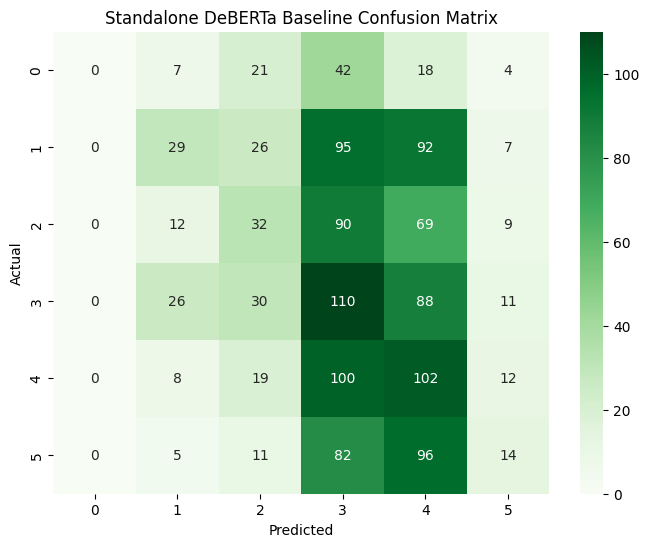

In [ ]:
# ==========================================================
# Standalone DeBERTa Baseline (Linguistic Only)
# Dataset: LIAR (Textual Statement Only)
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import DebertaV2Tokenizer, DebertaV2Model
from sklearn.metrics import f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Reproducibility ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---------------- Dataset Loading ----------------
# (Assuming LIAR folder is at /content/LIAR as per your previous setup)
DATA_DIR = "/content/LIAR"
cols = ['id','label','statement','subject','speaker','job_title',
        'state_info','party_affiliation','barely_true_counts',
        'false_counts','half_true_counts','mostly_true_counts',
        'pants_on_fire_counts', 'context']

label_map = {
    'pants-fire':0, 'false':1, 'barely-true':2,
    'half-true':3, 'mostly-true':4, 'true':5
}

def load_liar_df(path):
    df = pd.read_csv(path, sep='\t', names=cols)
    df.fillna("NaN", inplace=True)
    df['label'] = df['label'].map(label_map)
    return df

train_df = load_liar_df(f"{DATA_DIR}/train.tsv")
test_df  = load_liar_df(f"{DATA_DIR}/test.tsv")

# ---------------- Tokenizer ----------------
# Using DeBERTa-v3-small for fair comparison with the paper's BERT experiments
tokenizer = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-small")

class DebertaOnlyDataset(Dataset):
    def __init__(self, df, max_len=64):
        self.texts = df["statement"].tolist()
        self.labels = df["label"].tolist()
        self.max_len = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ---------------- Model Definition ----------------
class DebertaBaseline(nn.Module):
    def __init__(self, num_labels=6):
        super().__init__()
        self.deberta = DebertaV2Model.from_pretrained("microsoft/deberta-v3-small")
        # Freeze backbone to focus on classification head (as often done in baselines)
        for param in self.deberta.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(self.deberta.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, ids, mask):
        outputs = self.deberta(input_ids=ids, attention_mask=mask)
        # Use CLS token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output.float())

# ---------------- Evaluation ----------------
def evaluate_baseline(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask, y = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['label'].to(DEVICE)
            logits = model(ids, mask)
            preds = logits.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y.cpu().numpy())

    acc = np.mean(np.array(y_pred) == np.array(y_true))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return acc, macro_f1, y_true, y_pred

# ---------------- Training Logic ----------------
train_loader = DataLoader(DebertaOnlyDataset(train_df), batch_size=16, shuffle=True)
test_loader = DataLoader(DebertaOnlyDataset(test_df), batch_size=16)

model = DebertaBaseline().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

print("\nStarting DeBERTa Baseline Training...")
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in train_loader:
        ids, mask, y = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['label'].to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    acc, f1, _, _ = evaluate_baseline(model, test_loader)
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

# Final Results
acc, f1, y_true, y_pred = evaluate_baseline(model, test_loader)
print("\n=========== FINAL BASELINE RESULTS ===========")
print(f"Accuracy: {acc:.4f}")
print(f"Macro-F1: {f1:.4f}")

# ---------------- Confusion Matrix ----------------
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Standalone DeBERTa Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

# ==========================================
# PHASE 1: TRAIN THE BASE MODEL FIRST
# ==========================================
print("--- Phase 1: Training Base FDHN ---")
# Instantiate a fresh model
fdhn_model = FDHN().to(DEVICE)
optimizer = torch.optim.Adam(fdhn_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Train for 5 epochs (Adjust if needed)
for epoch in range(5):
    fdhn_model.train()
    total_correct, total = 0, 0
    for t, mt, mn, y in train_loader:
        t, mt, mn, y = t.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = fdhn_model(t, mt, mn)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
    print(f"Epoch {epoch+1} Base Train Acc: {total_correct/total:.4f}")

# ==========================================
# PHASE 2: WRAP THE TRAINED MODEL
# ==========================================
print("\n--- Phase 2: Applying Novelty Wrapper ---")

class NovelFDHNWrapper(nn.Module):
    def __init__(self, trained_fdhn_model):
        super().__init__()
        self.model = trained_fdhn_model

    def forward(self, text_input, meta_text, meta_num):
        # 1. Linguistic Analysis Pass
        text_logits = self.model.tc1(text_input)
        probs = F.softmax(text_logits, dim=1)
        max_prob, pred_class = torch.max(probs, dim=1)

        # 2. Multimodal / Fuzzy Pass [cite: 65, 295, 263]
        o2 = self.model.tc2(meta_text)
        o3 = self.model.cb(meta_num)
        o4 = self.model.fz(o3)
        multimodal_logits = self.model.fc(torch.cat([text_logits, o2, o3, o4], 1))

        # 3. Dynamic Batch Thresholding [cite: 230, 408]
        # Check if the max linguistic probability is below our confidence threshold
        is_fuzzy_mask = (max_prob < 0.85).unsqueeze(1)

        final_logits = torch.where(is_fuzzy_mask, multimodal_logits, text_logits)
        decision_types = ["Fuzzy Hand-off" if fuzzy else "Linguistic Expert" for fuzzy in is_fuzzy_mask.squeeze(1).tolist()]

        # 4. Cross-Modal Consistency Check (Trust Score) [cite: 263, 411]
        with torch.no_grad():
            similarity = F.cosine_similarity(text_logits, o3)
            trust_scores = (similarity + 1) / 2 # Scale from [-1, 1] to [0, 1]

        return final_logits, decision_types, trust_scores, probs

# Initialize the wrapper using the TRAINED fdhn_model
novel_system = NovelFDHNWrapper(fdhn_model).to(DEVICE)

# ==========================================
# PHASE 3: EVALUATE THE NOVELTY SYSTEM
# ==========================================
def evaluate_novelty_on_liar(novel_model, test_loader):
    novel_model.eval()
    results = []

    print(f"Starting evaluation on {len(test_loader)} batches... Please wait.")

    with torch.no_grad():
        for i, (t, mt, mn, y) in enumerate(test_loader):
            t, mt, mn, y = t.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE), y.to(DEVICE)

            logits, decision_types, trust_scores, probs = novel_model(t, mt, mn)

            preds = logits.argmax(1).cpu().numpy()
            actuals = y.cpu().numpy()
            trusts = trust_scores.cpu().numpy()

            for j in range(len(preds)):
                results.append({
                    'Actual': actuals[j],
                    'Predicted': preds[j],
                    'Correct': preds[j] == actuals[j],
                    'Decision_Path': decision_types[j],
                    'Trust_Score': trusts[j]
                })

    df_results = pd.DataFrame(results)

    print("\n=======================================")
    print("--- Decision Path Breakdown ---")
    print(df_results['Decision_Path'].value_counts())

    print("\n--- Accuracy by Decision Path (%) ---")
    print(df_results.groupby('Decision_Path')['Correct'].mean() * 100)

    print("\n--- Average Trust Score ---")
    correct_trust = df_results[df_results['Correct']]['Trust_Score'].mean()
    incorrect_trust = df_results[~df_results['Correct']]['Trust_Score'].mean()
    print(f"Correct Predictions:   {correct_trust:.4f}")
    print(f"Incorrect Predictions: {incorrect_trust:.4f}")
    print("=======================================")

    return df_results

# Execute the evaluation
liar_results_df = evaluate_novelty_on_liar(novel_system, test_loader)

--- Phase 1: Training Base FDHN ---
Epoch 1 Base Train Acc: 0.3490
Epoch 2 Base Train Acc: 0.4063
Epoch 3 Base Train Acc: 0.4086
Epoch 4 Base Train Acc: 0.4273
Epoch 5 Base Train Acc: 0.4395

--- Phase 2: Applying Novelty Wrapper ---
Starting evaluation on 80 batches... Please wait.

--- Decision Path Breakdown ---
Decision_Path
Fuzzy Hand-off       874
Linguistic Expert    393
Name: count, dtype: int64

--- Accuracy by Decision Path (%) ---
Decision_Path
Fuzzy Hand-off       44.736842
Linguistic Expert    17.048346
Name: Correct, dtype: float64

--- Average Trust Score ---
Correct Predictions:   0.5081
Incorrect Predictions: 0.4801


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DebertaV2Model
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import os

print("🚀 Initializing DeBERTa-Powered Training Pipeline...")

# --- 1. System Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Initialize Tokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")
VOCAB_SIZE = len(tokenizer)

# --- 2. Dataset Loading & Preprocessing ---
DATA_DIR = "./LIAR" # Ensure this points to your extracted LIAR dataset folder!
cols = ['id','label','statement','subject','speaker','job_title',
        'state_info','party_affiliation','barely_true_counts',
        'false_counts','half_true_counts','mostly_true_counts',
        'pants_on_fire_counts','context']

label_map = {'pants-fire':0,'false':1,'barely-true':2,'half-true':3,'mostly-true':4,'true':5}

def load_data(split):
    df = pd.read_csv(f"{DATA_DIR}/{split}.tsv", sep='\t', names=cols)
    df.fillna("NaN", inplace=True)
    count_cols = ['barely_true_counts','false_counts','half_true_counts','mostly_true_counts','pants_on_fire_counts']

    # Safe replacement for pandas future warnings
    for col in count_cols:
        df[col] = pd.to_numeric(df[col].replace("NaN", 0))

    df['label'] = df['label'].map(label_map)
    return df, count_cols

train_df, count_cols = load_data('train')
test_df, _ = load_data('test')

class LiarDataset(Dataset):
    def __init__(self, df):
        # Tokenize main text (Returns both input_ids AND attention_mask)
        encoded_text = tokenizer(df["statement"].tolist(), padding="max_length", truncation=True, max_length=64, return_tensors="pt")
        self.text_ids = encoded_text["input_ids"].long()
        self.text_mask = encoded_text["attention_mask"].long()

        # Tokenize metadata text
        meta_cols = ["subject","speaker","job_title","state_info","party_affiliation","context"]
        self.meta_text = torch.cat([tokenizer(df[c].tolist(), padding="max_length", truncation=True, max_length=10, return_tensors="pt")["input_ids"] for c in meta_cols], dim=1).long()

        # Process numerical history
        self.meta_num = torch.tensor(df[count_cols].values, dtype=torch.float)
        self.label = torch.tensor(df["label"].values, dtype=torch.long)

    def __len__(self): return len(self.label)

    def __getitem__(self, idx):
        mn = self.meta_num[idx]
        mn = mn / (mn.sum() + 1e-6) # Normalize
        return self.text_ids[idx], self.text_mask[idx], self.meta_text[idx], mn, self.label[idx]

print("Preparing DataLoaders...")
BATCH_SIZE = 16
train_loader = DataLoader(LiarDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(LiarDataset(test_df),  batch_size=BATCH_SIZE)

# --- 3. Model Architectures ---
class DeBERTaBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.deb = DebertaV2Model.from_pretrained("microsoft/deberta-v3-small")
        # Freeze backbone to prevent catastrophic memory usage and overfitting
        for param in self.deb.parameters():
            param.requires_grad = False
        self.fc = nn.Linear(self.deb.config.hidden_size, 6)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad(): # Double-lock the gradients
            outputs = self.deb(input_ids=input_ids, attention_mask=attention_mask)
            cls = outputs.last_hidden_state[:, 0, :].float() # Cast to float to avoid fp16 errors
        return self.fc(cls)

class TextCNN(nn.Module):
    def __init__(self, vocab=VOCAB_SIZE, emb=128):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(emb,128,k) for k in [3,4,5]])
        self.fc = nn.Linear(128*3, 6)
    def forward(self, x):
        x = self.embed(x).permute(0,2,1)
        x = torch.cat([F.max_pool1d(F.relu(c(x)), c(x).shape[2]).squeeze(2) for c in self.convs], 1)
        return self.fc(x)

class CNNBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(5,128)
        self.lstm = nn.LSTM(128,64,bidirectional=True,batch_first=True)
        self.out = nn.Linear(128,6)
    def forward(self, x):
        x = self.fc(x).unsqueeze(1)
        _,(h,_) = self.lstm(x)
        h = torch.cat((h[-2],h[-1]),1)
        return self.out(h)

class Fuzzy(nn.Module):
    def __init__(self):
        super().__init__()
        self.mu = nn.Parameter(torch.randn(6,6))
        self.sigma = nn.Parameter(torch.ones(6,6))
    def forward(self, x):
        x = x.unsqueeze(1)
        return torch.mean(torch.exp(-0.5*((x-self.mu)/self.sigma)**2),dim=-1)

class FDHN_DeBERTa(nn.Module):
    def __init__(self):
        super().__init__()
        self.deb = DeBERTaBranch()
        self.tc2 = TextCNN()
        self.cb  = CNNBiLSTM()
        self.fz  = Fuzzy()
        self.fc = nn.Linear(24,6)

class NovelFDHNWrapper(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.model = original_model

    def forward(self, input_ids, attention_mask, meta_text, meta_num):
        # 1. Linguistic Analysis Pass
        text_logits = self.model.deb(input_ids, attention_mask)
        probs = F.softmax(text_logits, dim=1)
        max_prob, _ = torch.max(probs, dim=1)

        # 2. Dynamic Batch Thresholding
        is_fuzzy_mask = (max_prob < 0.85).unsqueeze(1)

        # 3. Multimodal Pass
        o2 = self.model.tc2(meta_text)
        o3 = self.model.cb(meta_num)
        o4 = self.model.fz(o3)
        multimodal_logits = self.model.fc(torch.cat([text_logits, o2, o3, o4], 1))

        final_logits = torch.where(is_fuzzy_mask, multimodal_logits, text_logits)

        with torch.no_grad():
            similarity = F.cosine_similarity(text_logits, o3)
            trust_scores = (similarity + 1) / 2

        return final_logits, None, trust_scores, probs

# --- 4. Training & Evaluation Loops ---
def evaluate(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for t_ids, t_mask, mt, mn, y in dataloader:
            t_ids, t_mask, mt, mn = t_ids.to(DEVICE), t_mask.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE)
            logits, _, _, _ = model(t_ids, t_mask, mt, mn)
            preds = logits.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y.numpy())

    acc = np.mean(np.array(y_pred) == np.array(y_true))
    macro = f1_score(y_true, y_pred, average="macro")
    return acc, macro

print("\n⚙️ Building the Model Pipeline...")
base_model = FDHN_DeBERTa()
novel_system = NovelFDHNWrapper(base_model).to(DEVICE)

# Note: Using a slightly higher learning rate than raw transformers since the backbone is frozen
optimizer = torch.optim.Adam(novel_system.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

epochs = 5
print(f"🔥 Starting Training for {epochs} Epochs...")

for epoch in range(epochs):
    novel_system.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for i, (t_ids, t_mask, mt, mn, y) in enumerate(train_loader):
        t_ids, t_mask, mt, mn, y = t_ids.to(DEVICE), t_mask.to(DEVICE), mt.to(DEVICE), mn.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits, _, _, _ = novel_system(t_ids, t_mask, mt, mn)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    train_acc = total_correct / total_samples

    # Run evaluation on the test set to monitor for overfitting
    test_acc, test_macro = evaluate(novel_system, test_loader)

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Test Macro-F1: {test_macro:.4f}")

# --- 5. Save the Brain ---
print("\n💾 Saving trained weights...")
torch.save(novel_system.state_dict(), 'novel_deberta_model.pth')
print("✅ SUCCESS! Model saved as 'novel_deberta_model.pth'.")
print("You can now safely run: streamlit run app.py")

🚀 Initializing DeBERTa-Powered Training Pipeline...
Using device: cuda


/tmp/ipython-input-2000/1942155002.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NaN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("NaN", inplace=True)
/tmp/ipython-input-2000/1942155002.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace("NaN", 0))


Preparing DataLoaders...

⚙️ Building the Model Pipeline...


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

🔥 Starting Training for 5 Epochs...
Epoch 1 | Train Acc: 0.3048 | Test Acc: 0.3757 | Test Macro-F1: 0.3461
Epoch 2 | Train Acc: 0.4314 | Test Acc: 0.4278 | Test Macro-F1: 0.3970
Epoch 3 | Train Acc: 0.4548 | Test Acc: 0.4357 | Test Macro-F1: 0.4357
Epoch 4 | Train Acc: 0.4740 | Test Acc: 0.4207 | Test Macro-F1: 0.4224
Epoch 5 | Train Acc: 0.4909 | Test Acc: 0.4262 | Test Macro-F1: 0.4334

💾 Saving trained weights...
✅ SUCCESS! Model saved as 'novel_deberta_model.pth'.
You can now safely run: streamlit run app.py


In [ ]:
torch.save(novel_system.state_dict(), 'novel_model.pth')